# Analisi NLP sui tweet per Emoji Prediction, Named Entities Recognition & Relazioni Semantiche

In questo progetto analizziamo *5.000 tweet dello split di validazione* del dataset `tweet_eval` (**configurazione emoji**), con l’obiettivo di esplorare la relazione tra contenuto testuale  e le 20 etichette emoji associate alle classi (0-19).

Usando strumenti di NLP ( spaCy, NLTK e WordNet) per l'analisi linguistica, ci siamo concentrati sulla `distribuzione di hashtag e menzioni in relazione alle etichette`,e abbiamo implementato una `classificazione tramite embedding preaddestrato e una rete neurale semplice` (MLPClassifier).

Sono inclusi anche grafici esplicativi e un focus finale sulle parole più frequenti, arricchito da **relazioni semantiche tratte da WordNet**.

### Cominciamo importando le librerie necessarie, incluse le risorse linguistiche

Oltre alle librerie per la NLP menzionate sopra, importiamo strumenti per la manipolazione dati (`pandas`, `re`), la visualizzazione (`matplotlib`, con cui **impostiamo un font uniforme per tutti i grafici** tramite `plt.rcParams`) e per la classificazione (`scikit-learn`, `sentence-transformers`) 

Inoltre, inizializziamo il modello `spaCy` base (`en_core_web_sm`) per tokenizzazione e Named Entity Recognition, e carichiamo le stopwords dell'inglese da`nltk` per filtrare parole non significative.

In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "DejaVu Sans"
import spacy  # Per tokenizzazione, lemmatizzazione e Named Entity Recognition
from nltk.corpus import stopwords 
from nltk.corpus import wordnet as wn #solo analisi su parole più frequenti alla fine
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sentence_transformers import SentenceTransformer
from collections import defaultdict
import html #per eliminare problema con le entità &amp; e altre
from sklearn.neural_network import MLPClassifier


nlp = spacy.load("en_core_web_sm")
stop_words = set(stopwords.words("english"))

2025-06-23 11:03:48.345769: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750676628.614399      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750676628.689333      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


### Caricamento e preparazione del dataset

Dopo aver *caricato il dataset* con la libreria `datasets` e i 5.000 tweet dello split di validazione dal dataset `tweet_eval` (**configurazione emoji**), li **convertiamo in un DataFrame Pandas** per una gestione più comoda, togliamo le eventuali **entità HTML** dai tweet (come `&amp;`) e **dividiamo il dataset in due metà**: una per simulare il training e una per il testing.

Abbiamo deciso di optare per una **mappatura label numerica-emoji tramite dizionario** che usiamo prima degli istogrammi per gli hashtag per mettere a schermo una **legenda** ed aiutare nella corrispondenza con le emoji, soprattutto inizialmente poiché `negli istogrammi i graphi per le emoji non erano tutti disponibili`. 

In [2]:

dataset = load_dataset("cardiffnlp/tweet_eval", "emoji", split="validation")
df = dataset.to_pandas()
df["text"] = df["text"].apply(html.unescape)

# Utilizziamo la funzione sample e drop come visto da StackOverflow
train_df = df.sample(frac=0.5, random_state=42)
test_df = df.drop(train_df.index)


label_to_emoji = {
    0: "❤", 1: "😍", 2: "😂", 3: "💕", 4: "🔥",
    5: "😊", 6: "😎", 7: "✨", 8: "💙", 9: "😘",
    10: "📷", 11: "🇺🇸", 12: "☀", 13: "💜", 14: "😉",
    15: "💯", 16: "😁", 17: "🎄", 18: "📸", 19: "😜"
}

README.md:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/2.61M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/3.05M [00:00<?, ?B/s]

validation-00000-of-00001.parquet:   0%|          | 0.00/282k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/45000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5000 [00:00<?, ? examples/s]

### Preprocessing Linguistico e primi elementi testuali
In questa prima fase stiamo **normalizzando e pulendo il testo**, *rimuovendo stopwords e simboli*, *filtrando le parole brevi*, *lemmatizziamo* e *salviamo in una nuova colonna* con cui poi calcoliamo le dieci parole più frequenti per l'analisi linguistica con Wordnet alla fine del flusso.

A seguire, **estriamo anche gli hastag (#) con regular expression**, per poi salvarli in una colonna separata. Entrambe le trasformazioni le applichiamo solo sul training set per l'analisi esplorativa.

In [3]:
# Funzione per pulire e lemmatizzare un testo
def lemmatizza_pulisci_tweet(tweet):
    doc = nlp(tweet)
    return [
        token.lemma_.lower()
        for token in doc
        if token.is_alpha and token.text.lower() not in stop_words and len(token.lemma_) > 2
    ]

train_df["lemmi"] = [lemmatizza_pulisci_tweet(tweet) for tweet in train_df["text"]]
test_df["lemmi"] = [lemmatizza_pulisci_tweet(tweet) for tweet in test_df["text"]]


def estrai_hashtag(tweet):
    return re.findall(r"#\w+", tweet)

train_df["hashtag"] = [estrai_hashtag(tweet) for tweet in train_df["text"]]

## Frequenza degli hashtag e loro distribuzione per etichetta

Costruiamo un **dizionario annidato con defaultdict** e la funzione anonima `lambda` per contare le frequenze del singolo hashtag per ogni etichetta numerica, dopodiché ***sommiamo** questi valori di frequenza totale indipendentemente dalla classe*, e ne visualizziamo la *distribuzione su tutte le 20 etichette possibili* (0–19) con un **istogramma** per ciascuno. 

Per la visualizzazione oltre label visuali per le etichette, la frequenza,e il titolo, usiamo metodi per rendere la visualizzazione più leggibile. 

Legenda: label → emoji
 0 → ❤
 1 → 😍
 2 → 😂
 3 → 💕
 4 → 🔥
 5 → 😊
 6 → 😎
 7 → ✨
 8 → 💙
 9 → 😘
10 → 📷
11 → 🇺🇸
12 → ☀
13 → 💜
14 → 😉
15 → 💯
16 → 😁
17 → 🎄
18 → 📸
19 → 😜


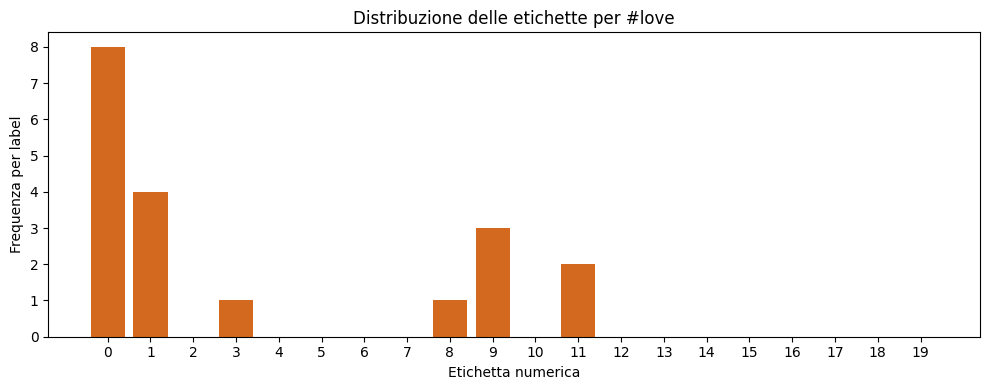

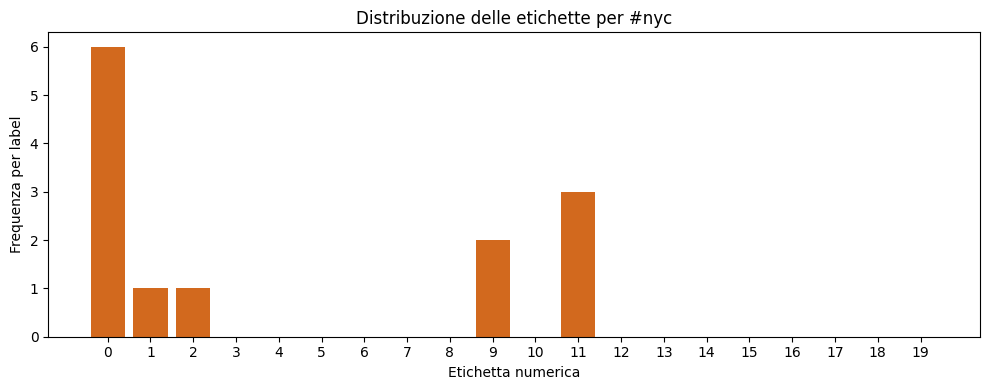

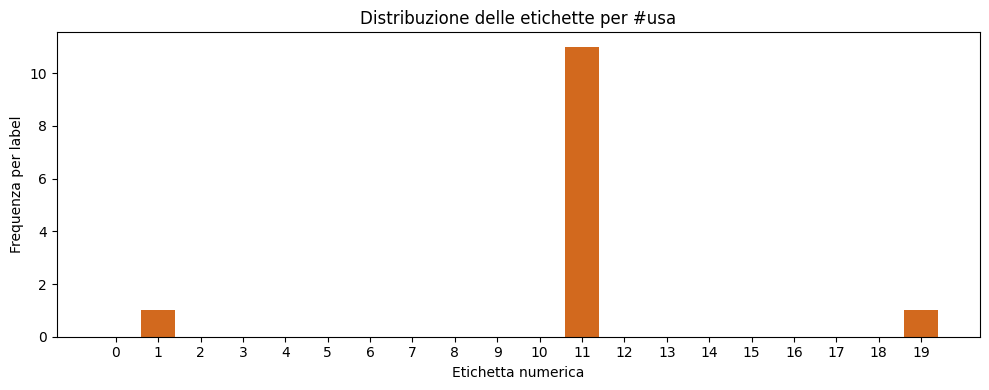

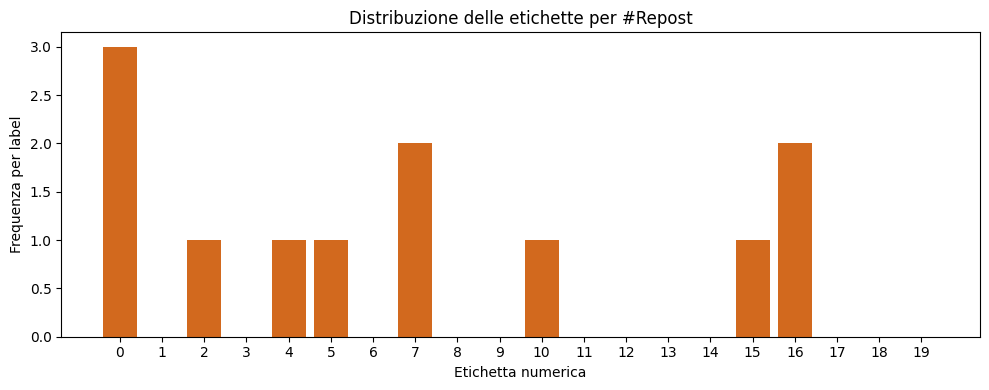

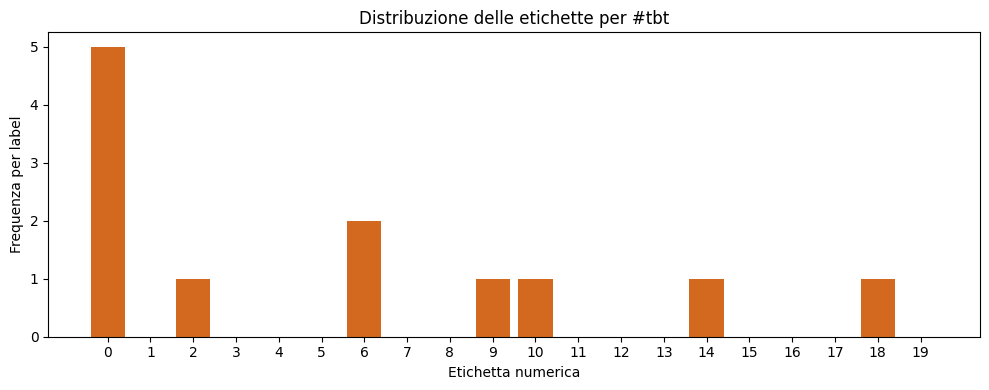

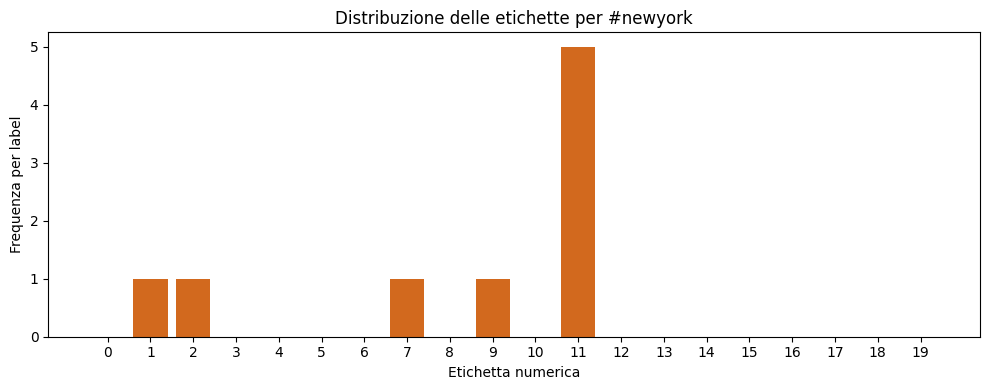

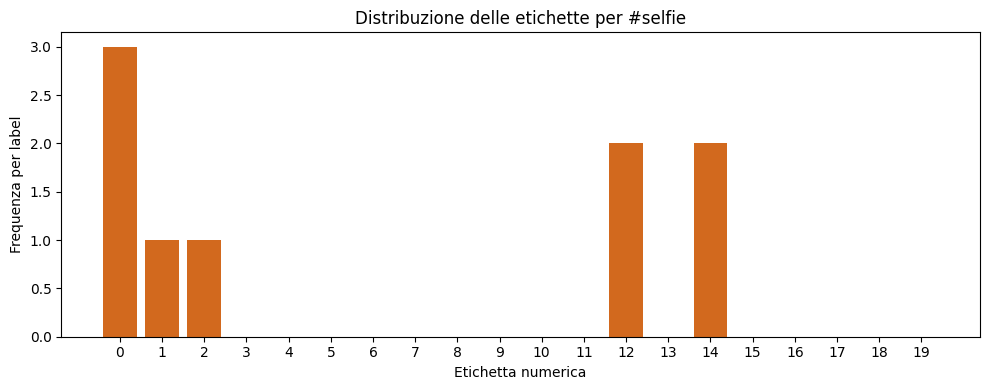

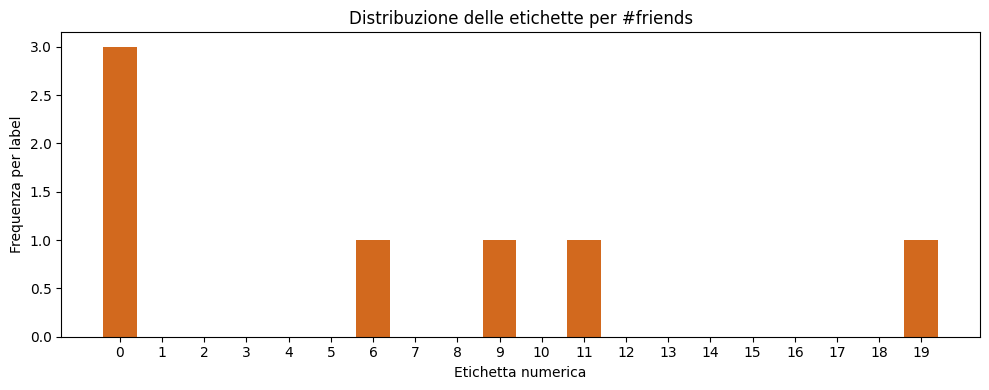

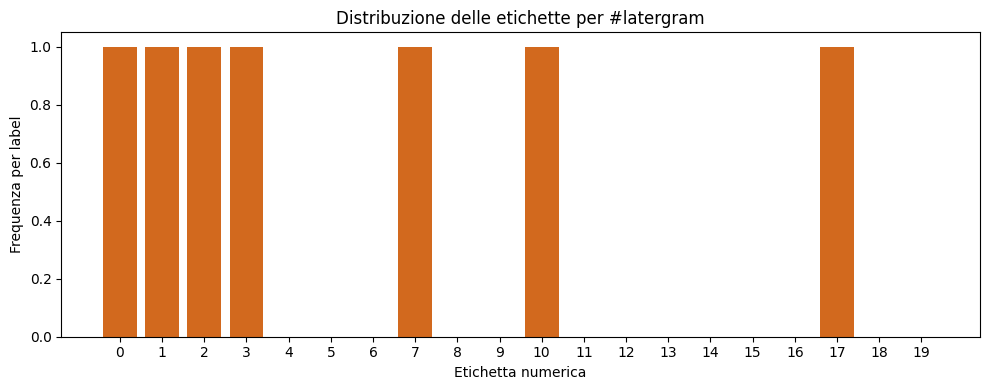

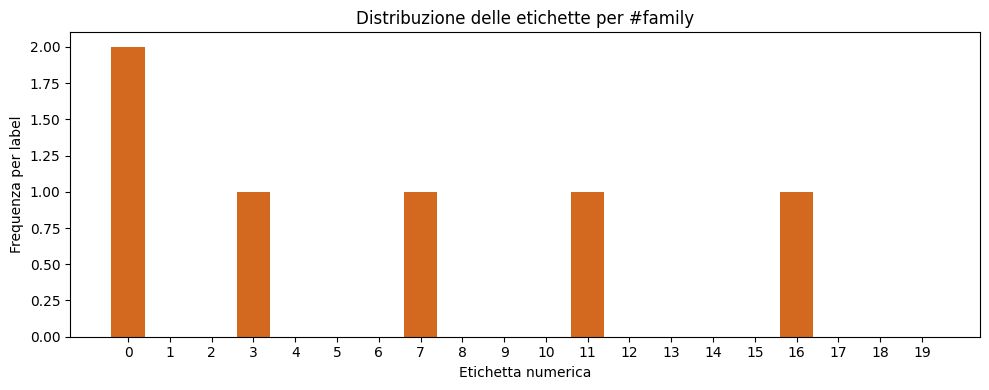

In [4]:
#Abbiamo un dizionario di dizionari per ogni nuovo hastag e la relazione con la label
dizionario_hashtag = defaultdict(lambda: defaultdict(int))

for i, riga_tweet in train_df.iterrows():
    lista_hashtag = riga_tweet["hashtag"]
    etichetta = riga_tweet["label"]

    for hashtag in lista_hashtag:
            dizionario_hashtag[hashtag][etichetta] += 1
        
# Calcoliamo la frequenza totale per ogni hashtag sommandoli per ottenere i 10 più frequenti
frequenze_totali_hashtag = {
    hashtag: sum(dizionario_hashtag[hashtag].values())
    for hashtag in dizionario_hashtag
}

top_10_hashtag = sorted(
    frequenze_totali_hashtag, key=frequenze_totali_hashtag.get,
    reverse=True
)[:10]

#Creiamo una legenda per aiutare nella corrispondenza delle etichette con le emoji

print("Legenda: label → emoji")
for i in range(20):
    print(f"{i:>2} → {label_to_emoji[i]}")
    
# Creiamo degli istogrammi per ognuno, su cui mettiamo le etichette numerate e le frequenze

for hashtag in top_10_hashtag:
    # Lista delle frequenze per ogni label da 0 a 19
    frequenze_per_label = [
        dizionario_hashtag[hashtag].get(i, 0)
        for i in range(20)]

    etichette_num = [str(i) for i in range(20)]

    # Istogramma per ognuno
    plt.figure(figsize=(10, 4))
    plt.bar(range(20), frequenze_per_label, color="#D2691E")  # Chocolate
    plt.xlabel("Etichetta numerica")
    plt.ylabel("Frequenza per label")
    plt.title(f"Distribuzione delle etichette per {hashtag}")
    plt.xticks(range(20), etichette_num)
    plt.tight_layout()
    plt.show()

## Frequenza delle entità e la loro distribuzione per Etichetta
Come già fatto per gli hashtag, ora costruiamo un `**dizionario annidato anche per le entità nominate**, estratte solo quando si trovano **dopo una menzione con @ (chiocciola + spazio)**. 

Anche qui, analizziamo la loro *frequenza in relazione alle label associate*, calcoliamo la *frequenza totale* e visualizziamo le *dieci entità più citate*.

Oltre la loro visualizzazione sotto forma di *istogramma* abbiamo **aggiunto prima una stampa a schermo** per facilitare la associazione con le emoji corrispondenti.

Entità: New York
  → Label 9 😘: 2 volte
  → Label 14 😉: 1 volte
  → Label 0 ❤: 5 volte
  → Label 11 🇺🇸: 1 volte
  → Label 6 😎: 2 volte
  → Label 10 📷: 1 volte
  → Label 7 ✨: 1 volte
  → Label 3 💕: 1 volte
  → Label 5 😊: 1 volte
  → Label 8 💙: 1 volte
----------------------------------------
Entità: Los Angeles
  → Label 16 😁: 1 volte
  → Label 7 ✨: 4 volte
  → Label 17 🎄: 2 volte
  → Label 2 😂: 2 volte
  → Label 8 💙: 1 volte
----------------------------------------
Entità: Disney
  → Label 7 ✨: 3 volte
  → Label 13 💜: 1 volte
  → Label 3 💕: 1 volte
----------------------------------------
Entità: Houston
  → Label 2 😂: 1 volte
  → Label 1 😍: 1 volte
  → Label 10 📷: 1 volte
  → Label 7 ✨: 1 volte
----------------------------------------
Entità: Disney's
  → Label 13 💜: 3 volte
  → Label 12 ☀: 1 volte
----------------------------------------
Entità: Athens
  → Label 0 ❤: 1 volte
  → Label 3 💕: 1 volte
  → Label 5 😊: 1 volte
----------------------------------------
Entità: Las Vegas
  → L

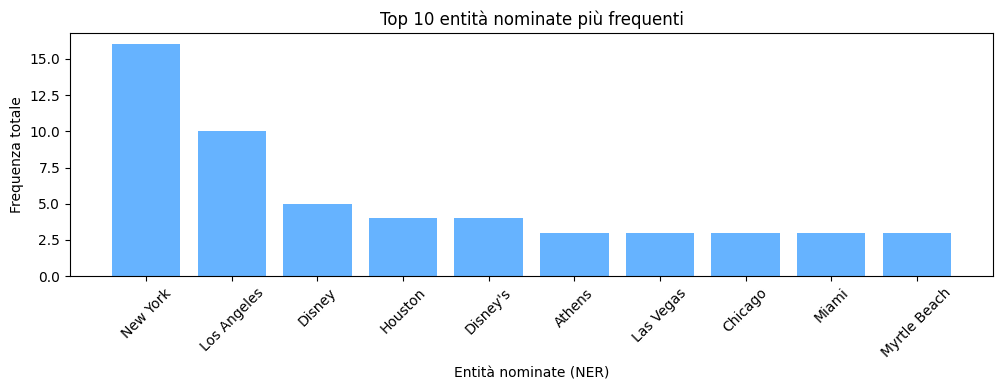

In [5]:
#Troviamo le entità nei tweet che due caratteri prima hanno @ + spazio e creiamo la colonna
def trova_entita_dopo_mention(tweet):
    doc = nlp(tweet)
    entita_menzionate = []
    for ent in doc.ents:
        inizio = ent.start_char
        if tweet[inizio - 2:inizio] == "@ ":
            entita_menzionate.append(ent.text)
    return entita_menzionate

train_df["entita_menzionate"] =[
        trova_entita_dopo_mention(tweet) for tweet in train_df["text"]
    ]
#Costruiamo un altro dizionario annidato per associare la entità alla label con conteggio
dizionario_entita = defaultdict(lambda:defaultdict(int))

for i, riga_tweet in train_df.iterrows():
    lista_entita = riga_tweet["entita_menzionate"]
    etichetta = riga_tweet["label"]

    for entita in lista_entita:
        dizionario_entita[entita][etichetta] += 1

# Calcoliamo la frequenza totale per ogni entità sommando i valori
frequenze_totali_entita = {
    entita: sum(dizionario_entita[entita].values()) for entita in dizionario_entita
}

# Prendiamo le 10 entità più citate in ordine inverso
top_10_entita = sorted(
    frequenze_totali_entita, key=frequenze_totali_entita.get, reverse=True)[:10]

# Stampiamo le 10 NE più frequenti e la loro distribuzione per label
for entita in top_10_entita:
    print(f"Entità: {entita}")
    for label, conteggio in dizionario_entita[entita].items():
        print(f"  → Label {label} {label_to_emoji[label]}: {conteggio} volte")
    print("-" * 40)

#abbiamo anche un istogramma per la loro visualizzazione
entita_top = top_10_entita # Alias per migliorare leggibilità nei grafici
frequenze_per_label = [frequenze_totali_entita[ent] for ent in entita_top]


plt.figure(figsize=(10, 4))
plt.bar(entita_top, frequenze_per_label, color="#66B3FF")
plt.xlabel("Entità nominate (NER)")
plt.ylabel("Frequenza totale")
plt.title("Top 10 entità nominate più frequenti")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Classificazione dei tweet con embedding e MLPClassifier

In questa sezione prepariamo i dati di addestramento e test prima trasformando gli oggeti Panda.Series in liste di stringhe per il calcolo degli embedding delle frasi con il modello `paraphrase-mpnet-base-v2`. Dopodiché addestriamo un classificatore `MLPClassifier` per la predizione delle etichette. Infine, valutiamo le performance con `report` e `Confusion Matrix`.

In [6]:
# Prepariamo i dati per l'embedding di ciascun tweet usando modello di embedding

X_train = train_df["text"].to_list()
y_train = train_df["label"].to_list()

X_test = test_df["text"].to_list()
y_test = test_df["label"].to_list()

model_embedding = SentenceTransformer("paraphrase-mpnet-base-v2")

embedding_X_train = model_embedding.encode(X_train)
embedding_X_test = model_embedding.encode(X_test)

# Abbiamo scelto di fare classificazione con MLPClassifier

clf = MLPClassifier(hidden_layer_sizes=(256,), random_state=42, max_iter=300)
clf.fit(embedding_X_train, y_train)
y_pred = clf.predict(embedding_X_test)

# Valutiamo la classificazione aggiungendo tre cifre decimali per aumentare precisione

print("Report di classificazione finale:")
print(classification_report(y_test, y_pred, digits=3))

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.52k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/594 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/79 [00:00<?, ?it/s]

Batches:   0%|          | 0/79 [00:00<?, ?it/s]

Report di classificazione finale:
              precision    recall  f1-score   support

           0      0.297     0.415     0.346       518
           1      0.181     0.184     0.183       255
           2      0.356     0.385     0.370       270
           3      0.071     0.085     0.077       142
           4      0.267     0.260     0.263       123
           5      0.097     0.098     0.098       112
           6      0.099     0.074     0.085       108
           7      0.098     0.078     0.086       103
           8      0.129     0.090     0.106        89
           9      0.040     0.024     0.030        83
          10      0.218     0.202     0.210        84
          11      0.231     0.234     0.233        64
          12      0.226     0.206     0.215        68
          13      0.071     0.048     0.058        83
          14      0.038     0.030     0.034        66
          15      0.127     0.100     0.112        70
          16      0.128     0.087     0.103    

## Considerazioni finali sulla classificazione

Nonostante l’uso di un buon modello di embedding contestuale (`paraphrase-mpnet-base-v2`) e di un classificatore MLP, i risultati della classificazione non sono particolarmente elevati (sotto il 50%). Anche testando un modello più potente come `cardiffnlp/twitter-roberta-base-emoji`, specificamente addestrato per compiti simili su tweet, i miglioramenti sono stati limitati.

Questo conferma la **complessità e il rumore tipici dei tweet**, che spesso contengono slang, abbreviazioni, simboli, emoji, riferimenti impliciti o culturali e una lunghezza ridotta. Queste features implicite rendono più difficile l’associazione tra testo e label in modo automatico.

Il modello ha comunque colto alcune relazioni generali tra testo e label, ma l’eterogeneità dei dati (dataset sbilanciato) richiederebbe approcci più avanzati di fine-tuning.

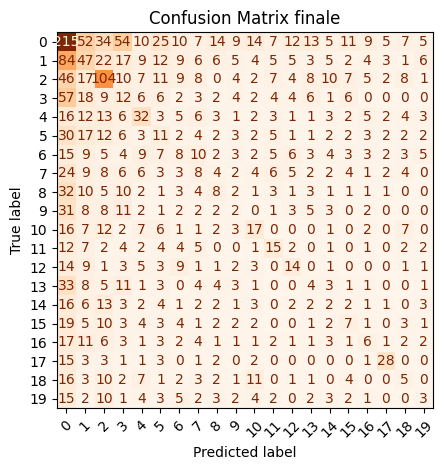

In [7]:
# Confusion Matrix finale per capire dove le classi sono state predette bene o non bene
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels= [str(i) for i in range(20)])
disp.plot(xticks_rotation=45, cmap="Oranges", colorbar=False)
plt.title("Confusion Matrix finale")
plt.tight_layout()
plt.show()

La `Confusion Matrix` mostra una **diagonale in parte visibile** (predizioni corrette), ma anche una **dispersione notevole**, segno delle difficoltà nel classificare tweet, un genere testuale breve, rumoroso e variegato. Questo riflette la complessità semantica e stilistica tipica dei contenuti sui social.

## Analisi semantica con WordNet sulle parole più frequenti

Come fase finale, abbiamo ripreso la colonna (`lemmi`) creata durante il preprocessing iniziale: ogni riga contiene una lista di lemmi per ciascun tweet. 

Abbiamo costruito un *dizionario di frequenze con defaultdict* e **selezionato le 10 parole più ricorrenti**, escludendo quelle troppo corte. 
Su queste abbiamo applicato un'analisi lessicale con **WordNet**, esplorando per ciascuna il **synset principale**, la *definizione*, eventuali *esempi d’uso*, e alcune *relazioni semantiche* (iperonimi, iponimi, antonimi).

In [8]:
# Analisi WordNet su parole più frequenti

# Creiamo un dizionario per contare tutte le parole lemmatizzate 
conteggio_parole = defaultdict(int)

for lista_lemmi in train_df["lemmi"]:
    for parola_lemmatizzata in lista_lemmi:
        conteggio_parole[parola_lemmatizzata] += 1

# Prendiamo le 10 parole più frequenti con almeno 3 caratteri e in ordine inverso
parole_frequenti = sorted(
    [p for p in conteggio_parole if len(p) > 2],
    key=conteggio_parole.get,
    reverse=True
)[:10]

# Stampiamo per ciascuna parola le info WordNet con le relazione semantiche di base
print("\n*** Analisi WordNet delle 10 parole più frequenti***:\n")

for parola in parole_frequenti:
    frequenza = conteggio_parole[parola]
    synsets = wn.synsets(parola)
    if synsets:
        primo_synset = synsets[0]
        print("\n" + "*" * 40)
        print(f"🔸 Parola: {parola}, Frequenza: {frequenza}")
        print(f"   → Nome synset: {primo_synset.name()}")
        print(f"   → Definizione: {primo_synset.definition()}")
        print(f"   →  Esempio: {primo_synset.examples()}")
        print("\n" + "*" * 40)

        iperonimi = primo_synset.hypernyms()
        iponimi = primo_synset.hyponyms()
        antonimi = primo_synset.lemmas()[0].antonyms()

        if iperonimi:
            print(f"   → Iperonimo: {iperonimi[0].name().split('.')[0]}")
        if iponimi:
            print(f"   → Iponimo: {iponimi[0].name().split('.')[0]}")
        if antonimi:
            print(f"   → Antonimo: {antonimi[0].name()}")

        print("-" * 40)
    else:
        print(f"🔸 Parola: {parola} → Nessun synset trovato\n" + "*" * 40)


*** Analisi WordNet delle 10 parole più frequenti***:


****************************************
🔸 Parola: love, Frequenza: 227
   → Nome synset: love.n.01
   → Definizione: a strong positive emotion of regard and affection
   →  Esempio: ['his love for his work', 'children need a lot of love']

****************************************
   → Iperonimo: emotion
   → Iponimo: puppy_love
   → Antonimo: hate
----------------------------------------

****************************************
🔸 Parola: new, Frequenza: 146
   → Nome synset: new.a.01
   → Definizione: not of long duration; having just (or relatively recently) come into being or been made or acquired or discovered
   →  Esempio: ['a new law', 'new cars', 'a new comet', 'a new friend', 'a new year', 'the New World']

****************************************
   → Antonimo: old
----------------------------------------

****************************************
🔸 Parola: good, Frequenza: 135
   → Nome synset: good.n.01
   → Definizio

### Considerazioni finali sull'analisi semantica

L’analisi delle 10 parole più frequenti ha evidenziato un vocabolario fortemente influenzato dalle emozioni e dal quotidiano tipico dei tweet, tra cui:  `love`, `happy`, `good` e `thank`.

La ricorrenza di `day` e `night` suggerisce una narrazione temporale, mentre la presenza di `new` e `get` può indicare una propensione alla novità e ai desideri,comunque molto comune nei social media.

Parole come `beach`, suggeriscono che è possibile che molti tweet facciano riferimento a esperienze estive, foto o ricordi (come prima abbiamo visto con gli hastag `#Repost` e `#tbt`-Throwback Thursday, in cui le persone condividono vecchie foto o ricordi sui social ogni giovedi').

Nella parola *york*,(sebbene ci si potesse aspettare *new york*), il lemmatizzatore ha separato i due termini e ha considerato *york* a sé stante. Questo dimostra che anche il preprocessing linguistico può introdurre ambiguità semantiche legate al contesto. Un'eventuale estensione potrebbe prevedere uso di tokenizer specifici per i social media (es. `TweetTokenizer`).